In [1]:
!pip install h5py -q
!pip install scikit-image -q
!pip install boto3 -q

In [2]:
!pip install 'meddlr[all]' -q

In [3]:
!pip install skm-tea -q

In [4]:
!pip install torchmetrics==0.11.4 torch==1.13.1+cu117 torchvision==0.14.1+cu117 torchtext==0.14.1 torchaudio==0.13.1 torchdata==0.5.1 --extra-index-url https://download.pytorch.org/whl/cu117


Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com, https://download.pytorch.org/whl/cu117
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 10.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 GB 868.5 kB/s eta 0:00:000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 8.7 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.1 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 28.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 119.2 MB/s eta 0:00:0000:01
  Attempting uninstall: torch
    Found existing installation: torch 2.0.0
    Uninstalling torch-2.0.0:
      Successfully uninstalled torch-2.0.0
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.15.1
    Uninstalling torchvision-0.15.1:
      Successfully uninstalled torchvision-0.15.1
  Attempting uninstall: 

In [5]:
!pip install "numpy<1.24"

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 41.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sagemaker 2.167.0 requires PyYAML==6.0, but you have pyyaml 5.4.1 which is incompatible.


In [6]:
import os
import random
import shutil
import time
import warnings
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from skimage.color import label2rgb
import torch
from tqdm.notebook import tqdm
from sklearn.model_selection import GroupKFold, KFold
import torch.nn as nn
import copy
import boto3
import json
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
import math
import skm_tea as st
from meddlr.data.data_utils import collect_mask
import timeit

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/skm_tea/data/register.py:418: UserWarning: SKM-TEA dataset was not properly registered. Please check that the dataset was properly downloaded and paths have been set. The error is shown below:
[Errno 2] No such file or directory: './datasets/skm-tea/v1-release/all_metadata.csv'
  warnings.warn(


In [7]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_h5(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.h5}"]
    """
    try:
        
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        with h5py.File(bytes_, "w") as f:
            
            echo1 = f["echo1"][()]
            segmentation = f["seg"][()] 
    
    except Exception as e: # work on python 3.x
        print("Failed to read numpy array from S3: "+ str(e))
    return echo1, segmentation

def pred_to_categorical(pred_or_logits, activation, channel_dim: int = 1, threshold: float = 0.5):
    """Converts one-hot encoded predictions or logits to category.

    Args:
        pred_or_logits: One-hot encoded predictions or logits. Shape BxCx...
        activation (str): Activation to use.
            Either ``'sigmoid'`` or ``'softmax'`` if ``pred_or_logits`` are logits.
            If `None` or '', assumes that `pred` does not need to be passed through
            activation function. If 'softmax', should include a background class.
        include_background (bool): If `True`, the first slice of class dimension (``C``)
            will not be dropped.
    """
    if activation not in [None, "", "sigmoid", "softmax"]:
        raise ValueError(f"activation '{activation}' not supported'")

    pred = pred_or_logits
    is_ndarray = isinstance(pred, np.ndarray)
    if is_ndarray:
        pred = torch.from_numpy(pred)

    if activation == "sigmoid":
        # TODO: Validate this case.
        out = one_hot_to_categorical(torch.sigmoid(pred) > threshold, channel_dim=channel_dim)
    elif activation == "softmax":
        out = torch.argmax(pred, dim=channel_dim)
    elif activation in (None, ""):
        # if not activation specified, assume it is one-hot encoded.
        out = one_hot_to_categorical(pred, channel_dim=channel_dim)
    else:
        raise ValueError(f"activation '{activation}' not supported'")

    if is_ndarray:
        out = out.numpy()
    return out

def one_hot_to_categorical(x, channel_dim: int = 1, background=False):
    """Converts one-hot encoded predictions to categorical predictions.

    Args:
        x (torch.Tensor | np.ndarray): One-hot encoded predictions.
        channel_dim (int, optional): Channel dimension.
            Defaults to ``1`` (i.e. ``(B,C,...)``).
        background (bool, optional): If ``True``, assumes index 0 in the
            channel dimension is the background.

    Returns:
        torch.Tensor | np.ndarray: Categorical array or tensor. If ``background=False``,
        the output will be 1-indexed such that ``0`` corresponds to the background.
    """
    is_ndarray = isinstance(x, np.ndarray)
    if is_ndarray:
        x = torch.as_tensor(x)

    if background is not None and background is not False:
        out = torch.argmax(x, channel_dim)
    else:
        out = torch.argmax(x.type(torch.long), dim=channel_dim) + 1
        out = torch.where(x.sum(channel_dim) == 0, torch.tensor([0], device=x.device), out)

    if is_ndarray:
        out = out.numpy()
    return out

In [8]:
s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [9]:
df_test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))
df_test

,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,tissues,file_name,msp_id,msp_file_name,scan_id,subject_id,split,sl,2d_bbox,yolo_bbox
0,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,Effusion,4,Effusion,NaN,MTR_173.h5,0000186_V00,0000186_V00.h5,MTR_173,186,test,20,"[131.0, 109.0, 120.0, 167.0]","[0.373046875, 0.3759765625, 0.234375, 0.326171..."
1,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,Effusion,4,Effusion,NaN,MTR_173.h5,0000186_V00,0000186_V00.h5,MTR_173,186,test,21,"[131.0, 109.0, 120.0, 167.0]","[0.373046875, 0.3759765625, 0.234375, 0.326171..."
2,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,Effusion,4,Effusion,NaN,MTR_173.h5,0000186_V00,0000186_V00.h5,MTR_173,186,test,22,"[131.0, 109.0, 120.0, 167.0]","[0.373046875, 0.3759765625, 0.234375, 0.326171..."
3,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,Effusion,4,Effusion,NaN,MTR_173.h5,0000186_V00,0000186_V00.h5,MTR_173,186,test,23,"[131.0, 109.0, 120.0, 167.0]","[0.373046875, 0.3759765625, 0.234375, 0.326171..."
4,18,16,-1,"[109.0, 131.0, 20.0, 167.0, 120.0, 38.0]",5.0,1,Effusion,4,Effusion,NaN,MTR_173.h5,0000186_V00,0000186_V00.h5,MTR_173,186,test,24,"[131.0, 109.0, 120.0, 167.0]","[0.373046875, 0.3759765625, 0.234375, 0.326171..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5291,17,16,-1,"[34.0, 111.0, 65.0, 244.0, 139.0, 77.0]",4.0,2,Effusion,4,Effusion,NaN,MTR_158.h5,0000169_V00,0000169_V00.h5,MTR_158,169,test,137,"[111.0, 34.0, 139.0, 244.0]","[0.3525390625, 0.3046875, 0.271484375, 0.4765625]"
5292,17,16,-1,"[34.0, 111.0, 65.0, 244.0, 139.0, 77.0]",4.0,2,Effusion,4,Effusion,NaN,MTR_158.h5,0000169_V00,0000169_V00.h5,MTR_158,169,test,138,"[111.0, 34.0, 139.0, 244.0]","[0.3525390625, 0.3046875, 0.271484375, 0.4765625]"
5293,17,16,-1,"[34.0, 111.0, 65.0, 244.0, 139.0, 77.0]",4.0,2,Effusion,4,Effusion,NaN,MTR_158.h5,0000169_V00,0000169_V00.h5,MTR_158,169,test,139,"[111.0, 34.0, 139.0, 244.0]","[0.3525390625, 0.3046875, 0.271484375, 0.4765625]"
5294,17,16,-1,"[34.0, 111.0, 65.0, 244.0, 139.0, 77.0]",4.0,2,Effusion,4,Effusion,NaN,MTR_158.h5,0000169_V00,0000169_V00.h5,MTR_158,169,test,140,"[111.0, 34.0, 139.0, 244.0]","[0.3525390625, 0.3046875, 0.271484375, 0.4765625]"


In [10]:
df_test.groupby(["tissue_id", "tissues"]).size().reset_index(name="counts")

,tissue_id,tissues,counts
0,1,Meniscus,691
1,2,ACL,251
2,3,PCL,78
3,4,Femoral Cartilage,658
4,5,Patellar Cartilage,643
5,6,Tibial Cartilage,372


In [11]:
df_test.scan_id.unique()

array(['MTR_173', 'MTR_176', 'MTR_178', 'MTR_188', 'MTR_196', 'MTR_198',
       'MTR_219', 'MTR_221', 'MTR_218', 'MTR_199', 'MTR_224', 'MTR_227',
       'MTR_235', 'MTR_237', 'MTR_240', 'MTR_241', 'MTR_244', 'MTR_248',
       'MTR_005', 'MTR_006', 'MTR_030', 'MTR_034', 'MTR_048', 'MTR_052',
       'MTR_065', 'MTR_066', 'MTR_079', 'MTR_080', 'MTR_096', 'MTR_099',
       'MTR_120', 'MTR_126', 'MTR_144', 'MTR_156', 'MTR_158'],
      dtype=object)

In [12]:
model = st.get_model_from_zoo(
    cfg_or_file="https://huggingface.co/arjundd/skm-tea-models/raw/main/neurips2021/segmentation-models/U-Net_E1/config.yaml",
    weights_path="https://huggingface.co/arjundd/skm-tea-models/resolve/main/neurips2021/segmentation-models/U-Net_E1/model.ckpt",
).eval()

In [13]:
model.cuda()

SkmTeaSemSegModule(
  (model): GeneralizedUNet(
    (down_blocks): ModuleDict(
      (block0): SimpleConvBlockNd(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block1): SimpleConvBlockNd(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block2): SimpleConvBlockNd(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): Batch

In [21]:
def make_prediction(scan_id, sl, verbose=True):
    
    t0 = time.time()
    
    echo1, segmentation = from_s3_h5("s3://skm-dataset/skm-tea/qdess/v1-release/image_files/" + scan_id + ".h5")
    num_correct = 0
    num_pixels  = 0
    dice_score  = 0
    
    echo1 = torch.as_tensor(echo1).unsqueeze(0).unsqueeze(0).float()
    echo1 = (echo1 - echo1.mean()) / echo1.std()
    echo1_sl = echo1[..., sl]

    gt_seg_sl = segmentation[..., sl, :]
    gt_seg_sl = collect_mask(gt_seg_sl, (0, 1, (4, 5), (2, 3)), out_channel_first=False)
    gt_seg_sl = one_hot_to_categorical(gt_seg_sl, channel_dim=-1)

    echo1_sl = echo1_sl.cuda()

    with torch.no_grad():
        logits = model({"image": echo1_sl})["sem_seg_logits"]
    
    prediction = pred_to_categorical(logits, activation="sigmoid").squeeze(0)
    pred = prediction.detach().cpu().numpy()
    
    num_correct += (pred == gt_seg_sl).sum()
    num_pixels += torch.numel(prediction)
    accuracy = num_correct / num_pixels
    
    intersection = np.logical_and(pred, gt_seg_sl)
    
    dice_score = (2 * intersection.sum() + 1e-7) / (pred.sum() + gt_seg_sl.sum() + 1e-7)
    dice_loss = 1 - dice_score
    
    diff = pred == gt_seg_sl
    diff_arr = np.where(diff, 1, 0)
    
    print(f"prediction time per slice: {time.time() - t0}")
    
    if verbose:
        _, axs = plt.subplots(1, 4, figsize=(16, 4))
        plt.suptitle(f"image = {scan_id}, slice = {sl}, loss = {dice_loss:0.4f}, accuracy = {accuracy:0.4f}")
        axs[0].imshow(echo1_sl.detach().cpu().numpy().squeeze(), cmap="bone")
        axs[0].axis("off")
        axs[0].set_title("Image", fontsize=16)
        
        axs[1].imshow(gt_seg_sl)
        axs[1].axis("off")
        axs[1].set_title("Mask", fontsize=16)
        
        axs[2].imshow(pred)
        axs[2].axis("off")
        axs[2].set_title("Prediction", fontsize=16)
        
        axs[3].imshow(diff_arr, cmap = "binary")
        axs[3].axis("off")
        axs[3].set_title("Difference", fontsize=16)

prediction time per slice: 2.2802693843841553


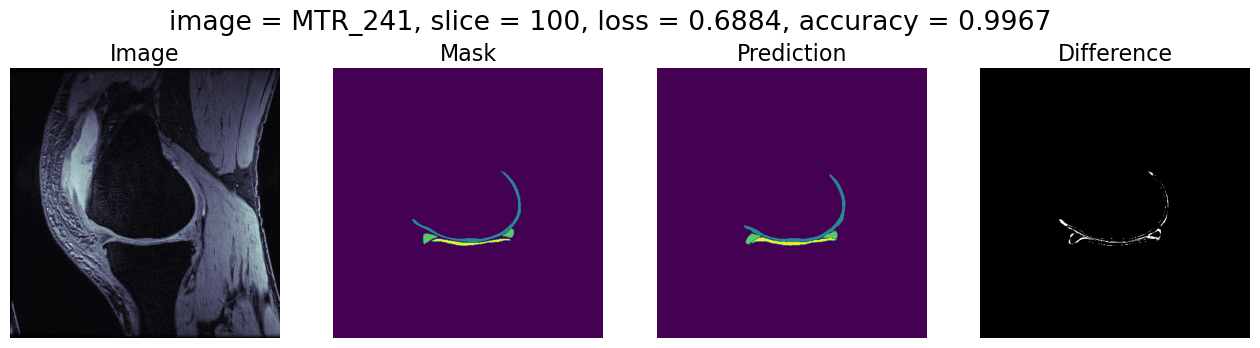

In [22]:
make_prediction("MTR_241", 100)

In [ ]:
"""
0 = background
1 = patellar cartilage
2 = femoral cartilage
3 = medial/lateral meniscus
4 = medial/lateral tibial cartilage
"""

In [23]:
def from_s3_read_h5_echo(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.h5}"]
    """
    try:
        
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        with h5py.File(bytes_, "w") as f:
            echo1 = f["echo1"][()]

    except Exception as e:
        print("Failed to read numpy array from S3: "+ str(e))
    return echo1

def write_file_to_s3(bucketName, fileContent, fileName, fileType=None, prefixName=None):
    """
        @param
        bucketName : s3 bucket
        fileContent : data to be written
        fileName   : output file Name
        fileType : optional; valid values : json (to write JSON file) 
                                            dataframe (to write df as csv file)
                                            None (any default file format)
        prefixName : optional; s3 prefix to bucket
    """
    try:
        if prefixName:
            fileName=prefixName+'/'+fileName
        if fileType=='json':
            response = client.put_object(Bucket=bucketName, #'testshi'
                                         Body=bytes(json.dumps(fileContent, default=str).encode('UTF-8')), #json.dumps(fileContent),  # '{"content": "bytes or seekable file-like object"}',
                                         Key=fileName)  #'test.json' # 'Object key for which the PUT operation was initiated'
        if fileType=='dataframe':
            fileContent.to_csv('s3://'+bucketName+'/'+fileName+'.csv', index=False)
        else:
            response = client.put_object( Bucket=bucketName, #'testshi'
                                         Body=fileContent, # '{"content": "bytes or seekable file-like object"}',
                                         Key=fileName) #'test.json' # 'Object key for which the PUT operation was initiated'
        print('Writing to S3 completed for ',fileName)
    except Exception as e: # work on python 3.x
        print('Failed to write numpy to S3: '+ str(e))
    return

def read_json_file_from_s3(bucketName, prefixName, fileName):
    """ returns json file content
        @param
        bucketName : s3 bucket
        prefixName : s3 prefix to bucket
        fileName   : input json file Name
        [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    result = client.list_objects(Bucket = bucketName, Prefix=prefixName)
    for o in result.get('Contents'):
        data = client.get_object(Bucket=bucketName, Key=o.get('Key'))
        contents = data['Body'].read()
    return json.loads(contents.decode("utf-8"))

In [24]:
def make_prediction_stack_ui(bucketName, prefixName, scan_id):
    # bucketName = "skm-dataset"
    # prefixName = "skm-tea/qdess/v1-release/image_files"
    # scan_id = "MTR_173"

    s3_url = "s3://" + bucketName + "/" + prefixName + "/" + scan_id + ".h5" 
    echo1 = from_s3_read_h5_echo(s3_url)
    echo1 = torch.as_tensor(echo1).unsqueeze(0).unsqueeze(0).float()
    echo1 = (echo1 - echo1.mean()) / echo1.std()

    metadata_summary = {}
    metadata_summary = {
        "image_id" : scan_id,
        "patellar cartilage": [],
        "femoral cartilage": [],
        "medial/lateral meniscus": [],
        "medial/lateral tibial cartilage": []
    }

    t1_start, t1_count = 0, 0
    t2_start, t2_count = 0, 0
    t3_start, t3_count = 0, 0
    t4_start, t4_count = 0, 0

    for sl in range(echo1.shape[-1]):

        tissue = [False, False, False, False]

        slice_no = sl+1

        metadata_sl = {}
        metadata_sl = {
            "image_id": scan_id,
            "slice_no": slice_no,
            "slice_info": []
        }

        echo1_sl = echo1[..., sl]
        echo1_sl = echo1_sl.cuda()

        with torch.no_grad():
            logits = model({"image": echo1_sl})["sem_seg_logits"]

        prediction = pred_to_categorical(logits, activation="sigmoid").squeeze(0)
        pred = prediction.detach().cpu().numpy()

        if 1 in np.unique(pred):
            tissue[0] = True
            if t1_start == 0:
                t1_start = sl+1
                t1_count = 1
            else:
                t1_count += 1

        if 2 in np.unique(pred):
            tissue[1] = True
            if t2_start == 0:
                t2_start = sl+1
                t2_count = 1
            else:
                t2_count += 1

        if 3 in np.unique(pred):
            tissue[2] = True
            if t3_start == 0:
                t3_start = sl+1
                t3_count = 1
            else:
                t3_count += 1

        if 4 in np.unique(pred):
            tissue[3] = True
            if t4_start == 0:
                t4_start = sl+1
                t4_count = 1
            else:
                t4_count += 1

        metadata_sl["slice_info"].append(
            {"pred_mask": pred.tolist(),
             "tissue": {"patellar cartilage":tissue[0], "femoral cartilage":tissue[1], "medial/lateral meniscus":tissue[2], "medial/lateral tibial cartilage":tissue[3]}
            }
        )
        
        metadata_sl_json = json.dumps(metadata_sl)

        outFileName_md_sl = scan_id + "_" + str(slice_no) + ".json"
        write_file_to_s3("stats-ui", metadata_sl_json, outFileName_md_sl, "json", "segmentation/sliceInfo/"+scan_id)

    metadata_summary["patellar cartilage"].append(
    {"start_sl": t1_start, "end_sl": t1_start + t1_count - 1, "slice_count": t1_count}
    )
    metadata_summary["femoral cartilage"].append(
        {"start_sl": t2_start, "end_sl": t2_start + t2_count - 1, "slice_count": t2_count}
    )
    metadata_summary["medial/lateral meniscus"].append(
        {"start_sl": t3_start, "end_sl": t3_start + t3_count - 1, "slice_count": t3_count}
    )
    metadata_summary["medial/lateral tibial cartilage"].append(
        {"start_sl": t4_start, "end_sl": t4_start + t4_count - 1, "slice_count": t4_count}
    )

    metadata_summary_json = json.dumps(metadata_summary)
    outSummaryFileName = scan_id + "_tissue_summary.json"
    write_file_to_s3("stats-ui", metadata_summary_json, outSummaryFileName, "json", "segmentation/summary")


In [30]:
t0 = time.time()
make_prediction_stack_ui("skm-dataset", "skm-tea/qdess/v1-release/image_files", "MTR_241")
print(f"prediction time per image file: {time.time() - t0}")

Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_1.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_2.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_3.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_4.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_5.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_6.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_7.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_8.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_9.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_10.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_11.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_12.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_13.json
Writing to S3 complet

In [32]:
read_json_file_from_s3("stats-ui", "segmentation/summary/MTR_241_tissue_summary.json", "MTR_241_tissue_summary.json")

{'image_id': 'MTR_241',
 'patellar cartilage': [{'start_sl': 32, 'end_sl': 87, 'slice_count': 56}],
 'femoral cartilage': [{'start_sl': 27, 'end_sl': 128, 'slice_count': 102}],
 'medial/lateral meniscus': [{'start_sl': 23,
   'end_sl': 118,
   'slice_count': 96}],
 'medial/lateral tibial cartilage': [{'start_sl': 23,
   'end_sl': 113,
   'slice_count': 91}]}

In [34]:
a=read_json_file_from_s3("stats-ui", "segmentation/sliceInfo/MTR_241/MTR_241_1.json", "MTR_241_1.json")
a["slice_info"][0]["tissue"]


{'patellar cartilage': False,
 'femoral cartilage': False,
 'medial/lateral meniscus': False,
 'medial/lateral tibial cartilage': False}

In [95]:
def make_prediction_stack_ui(bucketName, prefixName, scan_id):
    # bucketName = "skm-dataset"
    # prefixName = "skm-tea/qdess/v1-release/image_files"
    # scan_id = "MTR_173"

    s3_url = "s3://" + bucketName + "/" + prefixName + "/" + scan_id + ".h5" 
    echo1 = from_s3_read_h5_echo(s3_url)
    echo1 = torch.as_tensor(echo1).unsqueeze(0).unsqueeze(0).float()
    echo1 = (echo1 - echo1.mean()) / echo1.std()

    metadata_summary = {}
    metadata_summary = {
        "image_id" : scan_id,
        "patellar cartilage": [],
        "femoral cartilage": [],
        "medial/lateral meniscus": [],
        "medial/lateral tibial cartilage": []
    }

    t1_start, t1_count = 0, 0
    t2_start, t2_count = 0, 0
    t3_start, t3_count = 0, 0
    t4_start, t4_count = 0, 0

    #for sl in range(echo1.shape[-1] // 2):
    for sl in range(echo1.shape[-1] // 2, echo1.shape[-1]):

        tissue = [False, False, False, False]

        slice_no = sl+1

        metadata_sl = {}
        metadata_sl = {
            "image_id": scan_id,
            "slice_no": slice_no,
            "slice_info": []
        }

        echo1_sl = echo1[..., sl]
        echo1_sl = echo1_sl.cuda()

        with torch.no_grad():
            logits = model({"image": echo1_sl})["sem_seg_logits"]

        prediction = pred_to_categorical(logits, activation="sigmoid").squeeze(0)
        pred = prediction.detach().cpu().numpy()

        if 1 in np.unique(pred):
            tissue[0] = True
            if t1_start == 0:
                t1_start = sl+1
                t1_count = 1
            else:
                t1_count += 1

        if 2 in np.unique(pred):
            tissue[1] = True
            if t2_start == 0:
                t2_start = sl+1
                t2_count = 1
            else:
                t2_count += 1

        if 3 in np.unique(pred):
            tissue[2] = True
            if t3_start == 0:
                t3_start = sl+1
                t3_count = 1
            else:
                t3_count += 1

        if 4 in np.unique(pred):
            tissue[3] = True
            if t4_start == 0:
                t4_start = sl+1
                t4_count = 1
            else:
                t4_count += 1

        metadata_sl["slice_info"].append(
            {"pred_mask": pred.tolist(),
             "tissue": {"patellar cartilage":tissue[0], "femoral cartilage":tissue[1], "medial/lateral meniscus":tissue[2], "medial/lateral tibial cartilage":tissue[3]}
            }
        )

        metadata_sl_json = json.dumps(metadata_sl)

        outFileName_md_sl = scan_id + "_" + str(slice_no) + ".json"
        write_file_to_s3("stats-ui", metadata_sl_json, outFileName_md_sl, "json", "segmentation/sliceInfo/"+scan_id)

    
    outSummaryFileName = scan_id + "_tissue_summary.json"
    if outSummaryFileName in [f.split("/")[-1] for f in list_all_objects_in_s3("stats-ui", "segmentation/summary")]:
        metadata_summary = read_json_file_from_s3("stats-ui", "segmentation/summary/" + outSummaryFileName, outSummaryFileName)
        t1_start_p1 = metadata_summary["patellar cartilage"][0].get("start_sl")
        t1_end_p1 = metadata_summary["patellar cartilage"][0].get("end_sl")
        t1_count_p1 = metadata_summary["patellar cartilage"][0].get("slice_count")
        
        t2_start_p1 = metadata_summary["femoral cartilage"][0].get("start_sl")
        t2_end_p1 = metadata_summary["femoral cartilage"][0].get("end_sl")
        t2_count_p1 = metadata_summary["femoral cartilage"][0].get("slice_count")

        t3_start_p1 = metadata_summary["medial/lateral meniscus"][0].get("start_sl")
        t3_end_p1 = metadata_summary["medial/lateral meniscus"][0].get("end_sl")
        t3_count_p1 = metadata_summary["medial/lateral meniscus"][0].get("slice_count")
        
        t4_start_p1 = metadata_summary["medial/lateral tibial cartilage"][0].get("start_sl")
        t4_end_p1 = metadata_summary["medial/lateral tibial cartilage"][0].get("end_sl")
        t4_count_p1 = metadata_summary["medial/lateral tibial cartilage"][0].get("slice_count")
        
        metadata_summary["patellar cartilage"] = [{"start_sl": t1_start_p1, "end_sl": t1_end_p1 + t1_count, "slice_count": t1_count_p1 + t1_count}]
        metadata_summary["femoral cartilage"] = [{"start_sl": t2_start_p1, "end_sl": t2_end_p1 + t2_count, "slice_count": t2_count_p1 + t2_count}]
        metadata_summary["medial/lateral meniscus"] = [{"start_sl": t3_start_p1, "end_sl": t3_end_p1 + t3_count, "slice_count": t3_count_p1 + t3_count}]
        metadata_summary["medial/lateral tibial cartilage"] = [{"start_sl": t4_start_p1, "end_sl": t4_end_p1 + t4_count, "slice_count": t4_count_p1 + t4_count}]
    else:
        metadata_summary["patellar cartilage"].append(
        {"start_sl": t1_start, "end_sl": t1_start + t1_count - 1, "slice_count": t1_count}
        )
        metadata_summary["femoral cartilage"].append(
            {"start_sl": t2_start, "end_sl": t2_start + t2_count - 1, "slice_count": t2_count}
        )
        metadata_summary["medial/lateral meniscus"].append(
            {"start_sl": t3_start, "end_sl": t3_start + t3_count - 1, "slice_count": t3_count}
        )
        metadata_summary["medial/lateral tibial cartilage"].append(
            {"start_sl": t4_start, "end_sl": t4_start + t4_count - 1, "slice_count": t4_count}
        )

    metadata_summary_json = json.dumps(metadata_summary)
    
    write_file_to_s3("stats-ui", metadata_summary_json, outSummaryFileName, "json", "segmentation/summary")


In [93]:
t0 = time.time()
make_prediction_stack_ui("skm-dataset", "skm-tea/qdess/v1-release/image_files", "MTR_241")
print(f"prediction time per image file: {time.time() - t0}")

Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_1.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_2.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_3.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_4.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_5.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_6.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_7.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_8.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_9.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_10.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_11.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_12.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_13.json
Writing to S3 complet

In [96]:
t0 = time.time()
make_prediction_stack_ui("skm-dataset", "skm-tea/qdess/v1-release/image_files", "MTR_241")
print(f"prediction time per image file: {time.time() - t0}")

Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_81.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_82.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_83.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_84.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_85.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_86.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_87.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_88.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_89.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_90.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_91.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_92.json
Writing to S3 completed for  segmentation/sliceInfo/MTR_241/MTR_241_93.json
Writing to S

In [59]:
list_all_objects_in_s3("stats-ui", "t1")

['stats-ui/t1/MTR_241_tissue_summary.json', 'stats-ui/t1/test.json']

In [54]:
read_json_file_from_s3("stats-ui", "t1/MTR_241_tissue_summary.json", "MTR_241_tissue_summary.json")

{'image_id': 'MTR_241',
 'patellar cartilage': [{'start_sl': 32, 'end_sl': 80, 'slice_count': 49}],
 'femoral cartilage': [{'start_sl': 27, 'end_sl': 80, 'slice_count': 54}],
 'medial/lateral meniscus': [{'start_sl': 23,
   'end_sl': 72,
   'slice_count': 50}],
 'medial/lateral tibial cartilage': [{'start_sl': 23,
   'end_sl': 73,
   'slice_count': 51}]}

In [60]:
read_json_file_from_s3("stats-ui", "t1/MTR_241_tissue_summary.json", "MTR_241_tissue_summary.json")

{'image_id': 'MTR_241',
 'patellar cartilage': [{'start_sl': 32, 'end_sl': 87, 'slice_count': 56}],
 'femoral cartilage': [{'start_sl': 27, 'end_sl': 128, 'slice_count': 102}],
 'medial/lateral meniscus': [{'start_sl': 23,
   'end_sl': 118,
   'slice_count': 96}],
 'medial/lateral tibial cartilage': [{'start_sl': 23,
   'end_sl': 113,
   'slice_count': 91}]}

In [94]:
read_json_file_from_s3("stats-ui", "segmentation/summary/MTR_241_tissue_summary.json", "MTR_241_tissue_summary.json")

{'image_id': 'MTR_241',
 'patellar cartilage': [{'start_sl': 32, 'end_sl': 80, 'slice_count': 49}],
 'femoral cartilage': [{'start_sl': 27, 'end_sl': 80, 'slice_count': 54}],
 'medial/lateral meniscus': [{'start_sl': 23,
   'end_sl': 72,
   'slice_count': 50}],
 'medial/lateral tibial cartilage': [{'start_sl': 23,
   'end_sl': 73,
   'slice_count': 51}]}

In [97]:
read_json_file_from_s3("stats-ui", "segmentation/summary/MTR_241_tissue_summary.json", "MTR_241_tissue_summary.json")

{'image_id': 'MTR_241',
 'patellar cartilage': [{'start_sl': 32, 'end_sl': 87, 'slice_count': 56}],
 'femoral cartilage': [{'start_sl': 27, 'end_sl': 128, 'slice_count': 102}],
 'medial/lateral meniscus': [{'start_sl': 23,
   'end_sl': 118,
   'slice_count': 96}],
 'medial/lateral tibial cartilage': [{'start_sl': 23,
   'end_sl': 113,
   'slice_count': 91}]}